In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
import seaborn as sns

## exercício 1
Gere dados a partir de uma distribuição de Poisson. Varie a taxas $\lambda$ no intervalo [1,10] e mostre o gráfico da média em função da variância.

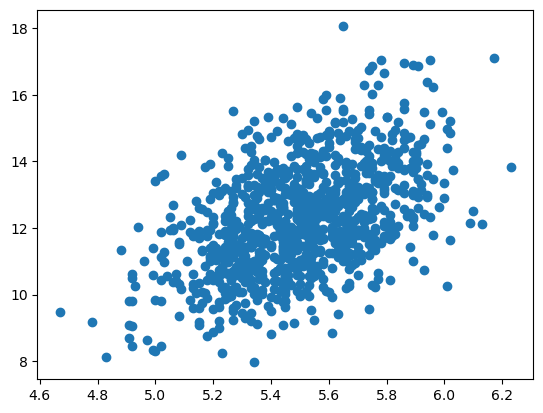

In [3]:
s=np.random.poisson(lam=np.linspace(1,10,100), size=(1000,100)) #one different lambda per column
plt.scatter(np.mean(s,axis=1), np.var(s,axis=1))

## exercício 2
Considere os dados da Iris. Calcule a média, variância e IQR para cada atributo. Obtenha o boxplot de todas as variáveis da flor Iris, para cada espécie.

In [10]:
data = pd.read_csv('data/iris.csv')
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


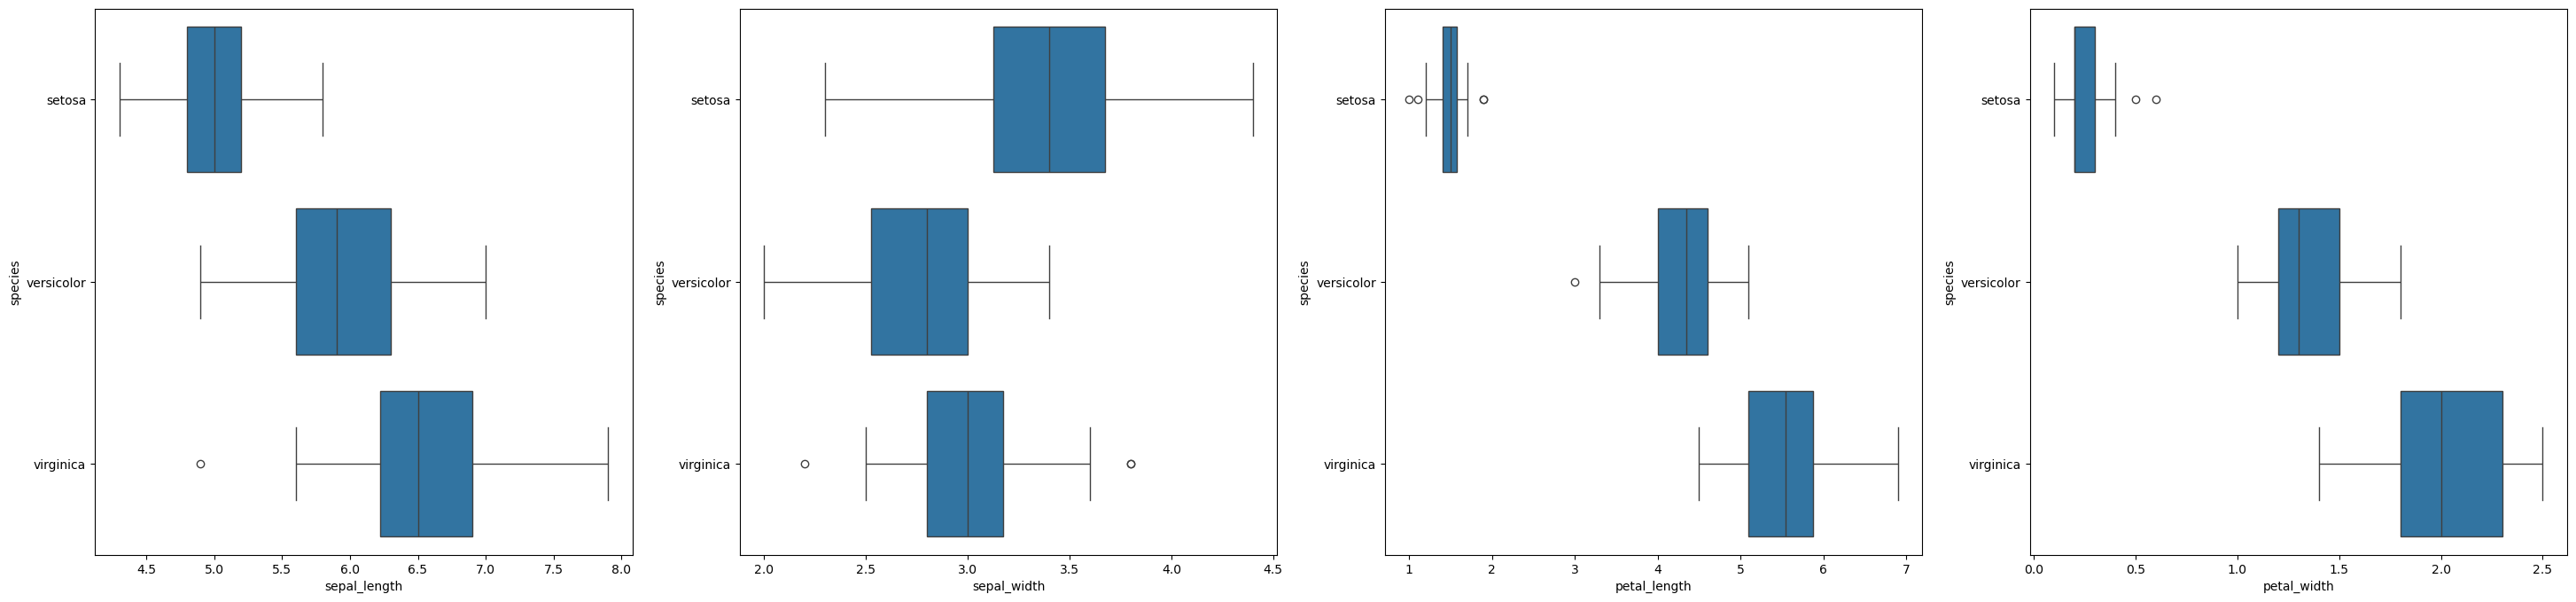

In [29]:
fig, axs = plt.subplots(nrows=1,ncols=len(data.columns)-1, figsize=(9*(len(data.columns)-1), 8))
count=0
for ax in axs:
    sns.boxplot(data=data,y='species',x=data.columns[count], ax=ax)
    count+=1

In [9]:
data = data.drop("species", axis=1)
stats = pd.DataFrame(index=['median', 'variance', 'IQR'], columns=data.columns)
stats.loc['median']=data.median()
stats.loc['variance']=data.var()
stats.loc['IQR']=sts.iqr(data, axis=0)
stats

,sepal_length,sepal_width,petal_length,petal_width
median,5.8,3.0,4.35,1.3
variance,0.685694,0.188004,3.113179,0.582414
IQR,1.3,0.5,3.5,1.5


## exercício 4
Para a função log(), investigue como as correlações de Pearson e Spearman variam de acordo com o intervalo dos dados.

In [31]:
from scipy.stats import pearsonr, spearmanr

In [62]:
x0=0
xfs = np.linspace(10.2, 100, 100)
yp=[]
ysp=[]
for xf in xfs:
    x = np.arange(xf-10,xf,0.05)
    logx = np.log(x)
    #print(logx)
    yp.append(pearsonr(x,logx)[0])
    ysp.append(spearmanr(x,logx)[0])

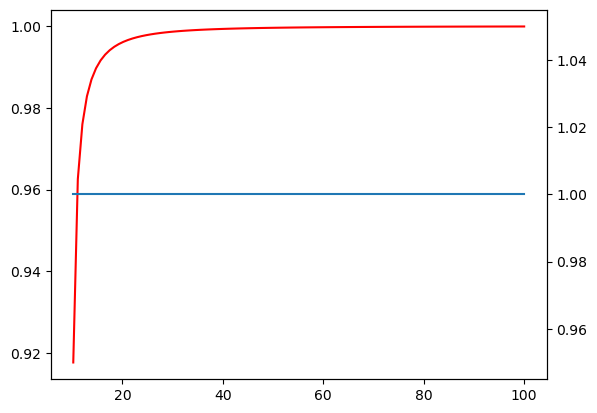

In [67]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(xfs, yp, color='red')
ax2.plot(xfs,ysp)

## exercício 6
Considere os dados abaixo, chamado quarteto de Ascomb. Calcule a média, variância, correlação de Pearson e Spearman entre as variáveis x e y. O que você pode dizer sobre esses dados?

I
media:  8.250454545454545 , corr pearson:  0.81642051634484 , corr spearman:  0.8181818181818182  

II
media:  8.250454545454545 , corr pearson:  0.8162365060002427 , corr spearman:  0.690909090909091  

III
media:  8.25 , corr pearson:  0.8162867394895982 , corr spearman:  0.990909090909091  

IV
media:  8.250454545454545 , corr pearson:  0.8165214368885029 , corr spearman:  0.5  



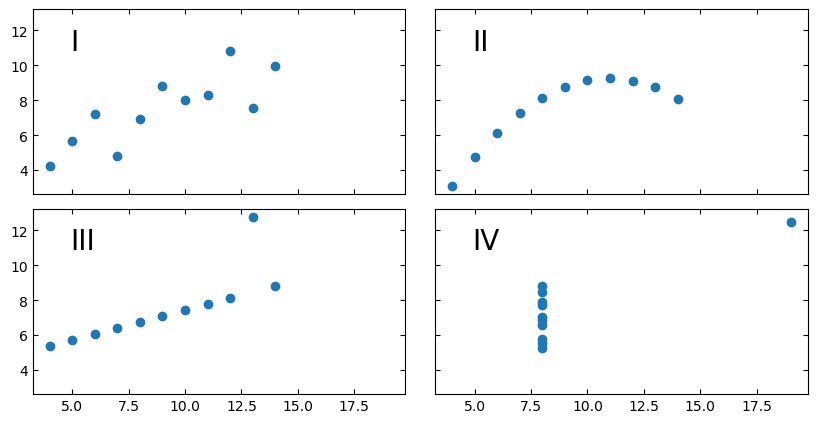

In [86]:
x = [10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5]
y1 = [8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68]
y2 = [9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74]
y3 = [7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73]
x4 = [8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8]
y4 = [6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89]

datasets = {
    'I': (x, y1),
    'II': (x, y2),
    'III': (x, y3),
    'IV': (x4, y4)
}

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 5),
                        gridspec_kw={'wspace': 0.08, 'hspace': 0.08})

for ax, (label, (x, y)) in zip(axs.flat, datasets.items()):
    ax.text(0.1, 0.9, label, fontsize=20, transform=ax.transAxes, va='top')
    ax.tick_params(direction='in', top=True, right=True)
    ax.plot(x, y, 'o')
    print(label)
    print("media: ", np.average((x,y)), ", corr pearson: ", pearsonr(x,y)[0], 
          ", corr spearman: ", spearmanr(x,y)[0]," \n")
plt.show()